# 📚 Importing Libraries

In [3]:
# 📚 Core Libraries
import os

# 📊 Data Handling
import pandas as pd
import numpy as np

# 🎨 Visualization
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = False


# 🛠️ Auxiliary Functions

In [ ]:
def load_simulation_data(N, avg_k, C, drop_node=True):
    """
    📂 load_simulation_data(int N, int avg_k, int C, bool drop_node=True)

    Loads all CSV files generated by the simulation from the directory:
    ./data/N{N}/k{avg_k}/C{C}/

    Each file is read into a DataFrame with the following columns:
    ["p", "m1", "m2", "m3", "m4", "s", "node1", "node2", "t"]

    Args:
        N (int): network size
        avg_k (int): average degree
        C (int): maximum cost
        drop_node (bool, optional): if True, drops "node1" and "node2" columns. Default is True.

    Returns:
        list[pd.DataFrame]: list of DataFrames loaded from all CSV files
    """
    data_dir = f'./data/N{N}/k{avg_k}/C{C}/'
    dfs = []

    for file_name in os.listdir(data_dir):
        df = pd.read_csv(
            os.path.join(data_dir, file_name), 
            sep=' ', 
            names=["p", "m1", "m2", "m3", "m4", "s", "node1", "node2", "t"])
        if drop_node is True:
            df.drop(['node1', 'node2'], axis=1, inplace=True)
        dfs.append(df)
    
    return dfs


def compute_average_curves(N, avg_k, C):
    """
    📊 compute_average_curves(int N, int avg_k, int C)

    Loads all simulation CSVs for a given configuration and computes
    the mean and standard deviation of all metrics grouped by "p".

    Args:
        N (int): network size
        avg_k (int): average degree
        C (int): maximum cost

    Returns:
        pd.DataFrame: DataFrame with mean and standard deviation 
                      for each value of "p".
                      Columns: ["p", "m1", "m2", "m3", "m4", "s", "t",
                                "m1_std", "m2_std", "m3_std", "m4_std", 
                                "s_std", "t_std"]
    """
    dfs = load_simulation_data(N, avg_k, C)
    combined_df = pd.concat(dfs)

    mean_df = combined_df.groupby("p").mean()
    std_df = combined_df.groupby("p").std()

    final_df = mean_df.merge(std_df, on="p", suffixes=("", "_std"))
    final_df = final_df.reset_index()
    
    return final_df


# 📥 Loading Data

Next, we will plot a specific realization of the generated data in order to observe a concrete use case.  
For this example, we will focus on the scenario where $N = 2048$ and the cost is $C = N$.

In [5]:
N, avg_k, C = 2048, 4, 2048

# Load simulation data
dfs = load_simulation_data(N=N, avg_k=avg_k, C=C)

# Compute averaged curves
final_df = compute_average_curves(N=N, avg_k=avg_k, C=C)
final_df.head()

,p,m1,m2,m3,m4,s,t,m1_std,m2_std,m3_std,m4_std,s_std,t_std
0,0.000244,0.983398,0.967072,0.951018,0.935229,1.058824,1.0,0.0,0.0,0.0,0.0,0.0,0.000000
1,0.000488,0.983398,0.967072,0.951018,0.935229,1.058824,1.0,0.0,0.0,0.0,0.0,0.0,0.000000
2,0.000732,0.983398,0.967072,0.951018,0.935229,1.058824,1.0,0.0,0.0,0.0,0.0,0.0,0.000000
3,0.000977,0.983398,0.967072,0.951018,0.935229,1.058824,1.1,0.0,0.0,0.0,0.0,0.0,0.316228
4,0.001221,0.983398,0.967072,0.951018,0.935229,1.058824,1.3,0.0,0.0,0.0,0.0,0.0,0.483046


# 📊 Plotting the selected realization


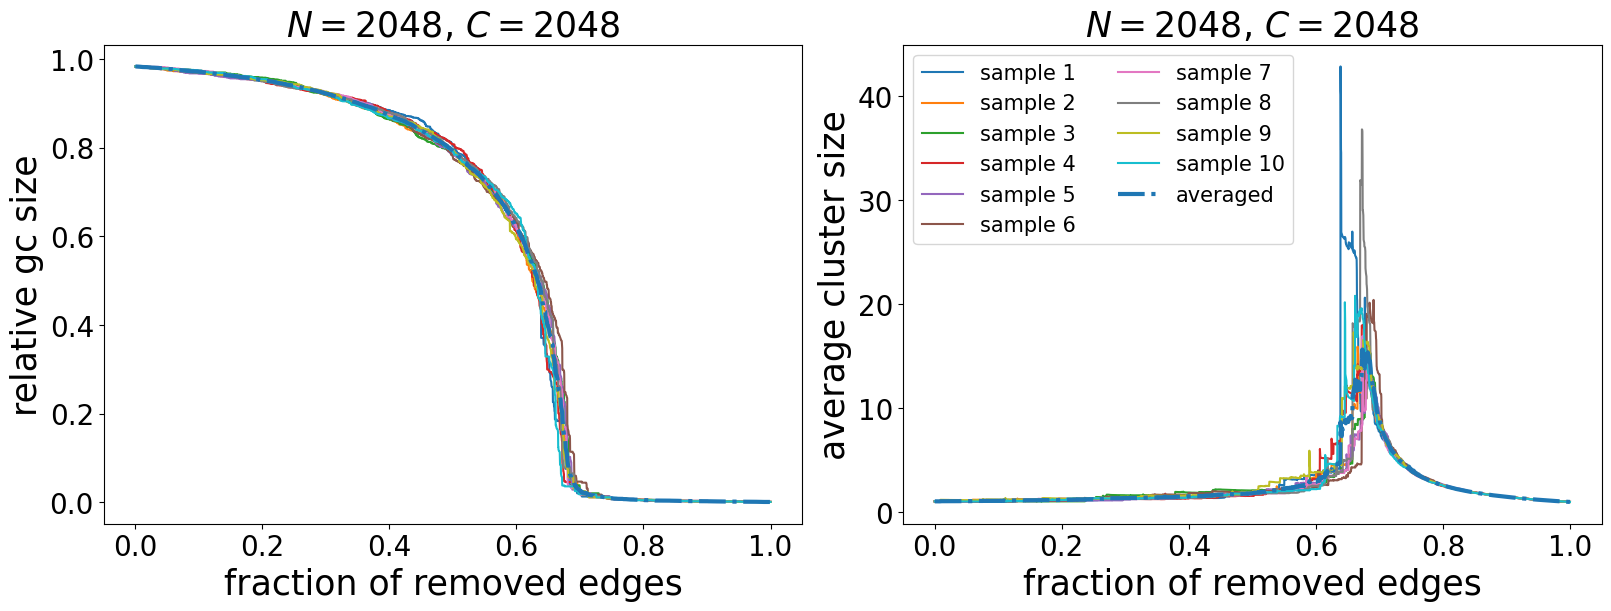

In [12]:
fig, ax = plt.subplots(ncols=2, figsize=(16, 6), constrained_layout=True)

for i, df in enumerate(dfs):
    ax[0].plot(df["p"], df["m1"], label=f'sample {i+1}')
    ax[1].plot(df["p"], df["s"], label=f'sample {i+1}')

ax[0].plot(final_df["p"], final_df["m1"], ls='-.', lw=3, label='averaged')
ax[1].plot(final_df["p"], final_df["s"], ls='-.', lw=3, label='averaged')

ax[0].set_title(f'${N = }$, ${C = }$', fontsize=25)
ax[0].set_xlabel('fraction of removed edges', fontsize=25)
ax[0].set_ylabel('relative gc size', fontsize=25)
ax[0].tick_params('both', labelsize=20)

ax[1].set_title(f'${N = }$, ${C = }$', fontsize=25)
ax[1].set_xlabel('fraction of removed edges', fontsize=25)
ax[1].set_ylabel('average cluster size', fontsize=25)
ax[1].tick_params('both', labelsize=20)
ax[1].legend(fontsize=15, ncol=2)

# 📉 Plotting the selected realization (using raw number of demands)

In this second visualization, instead of showing the evolution as a function of the **fraction of removed edges ($p$)**,  
we plot the results against the **raw number of demands ($t$)**.  

By using a **logarithmic scale** on the x-axis, we can clearly observe both the early stages (few demands)  
and the long-term behavior of the network, highlighting the phase transitions in the size of the largest component  
and the average cluster size.


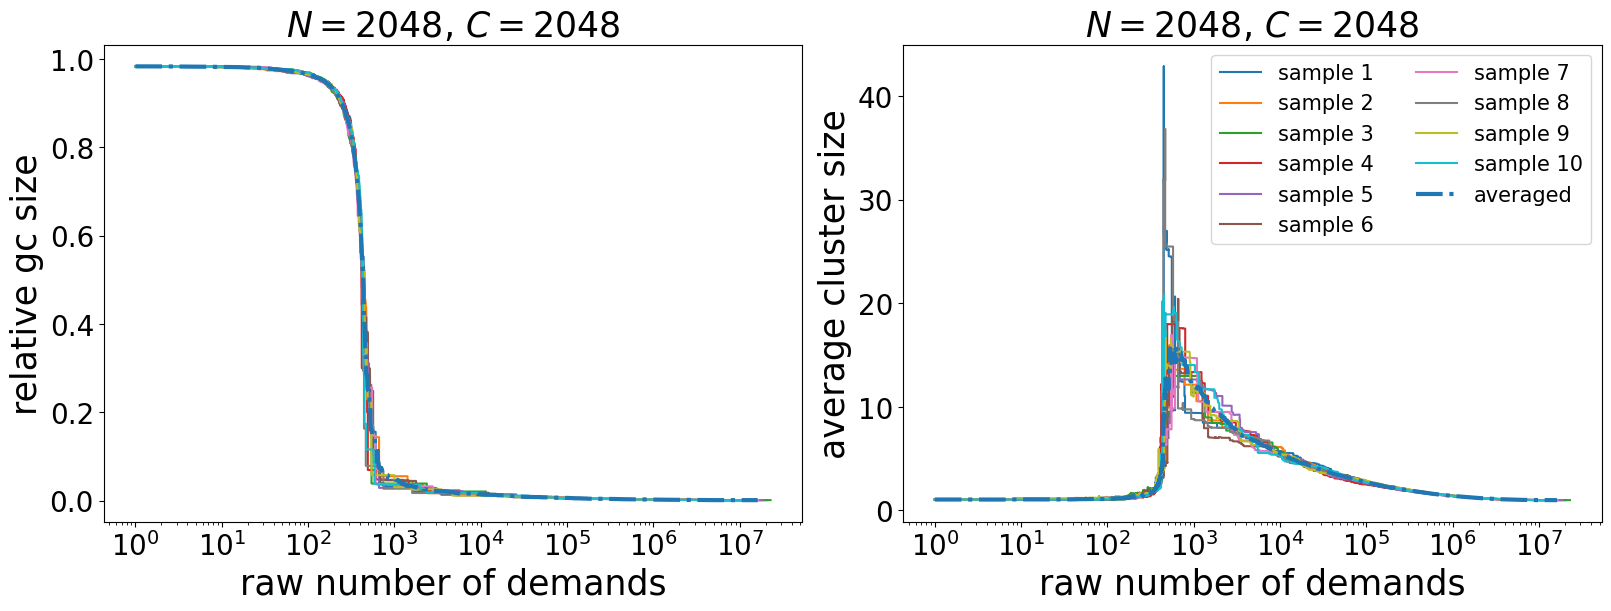

In [11]:
fig, ax = plt.subplots(ncols=2, figsize=(16, 6), constrained_layout=True)

for i, df in enumerate(dfs):
    ax[0].plot(df["t"], df["m1"], label=f'sample {i+1}')
    ax[1].plot(df["t"], df["s"], label=f'sample {i+1}')

ax[0].plot(final_df["t"], final_df["m1"], ls='-.', lw=3, label='averaged')
ax[1].plot(final_df["t"], final_df["s"], ls='-.', lw=3, label='averaged')

ax[0].set_title(f'${N = }$, ${C = }$', fontsize=25)
ax[0].set_xlabel('raw number of demands', fontsize=25)
ax[0].set_ylabel('relative gc size', fontsize=25)
ax[0].tick_params('both', labelsize=20)
ax[0].set_xscale('log')

ax[1].set_title(f'${N = }$, ${C = }$', fontsize=25)
ax[1].set_xlabel('raw number of demands', fontsize=25)
ax[1].set_ylabel('average cluster size', fontsize=25)
ax[1].tick_params('both', labelsize=20)
ax[1].legend(fontsize=15, ncol=2)
ax[1].set_xscale('log')

plt.show()

# 🔎 Comparing different values of $C$

In this analysis we fix the network size at **$N = 4096$** and compare the results for different cost values: $C = 1$, $C = 2$, $C = 3$, and $C = N$.  

The left panel shows the evolution of the **relative size of the giant component**, while the right panel displays the **average cluster size**.  

By contrasting these scenarios, we can observe how the choice of $C$ influences the robustness of the network and the nature of the percolation transition.


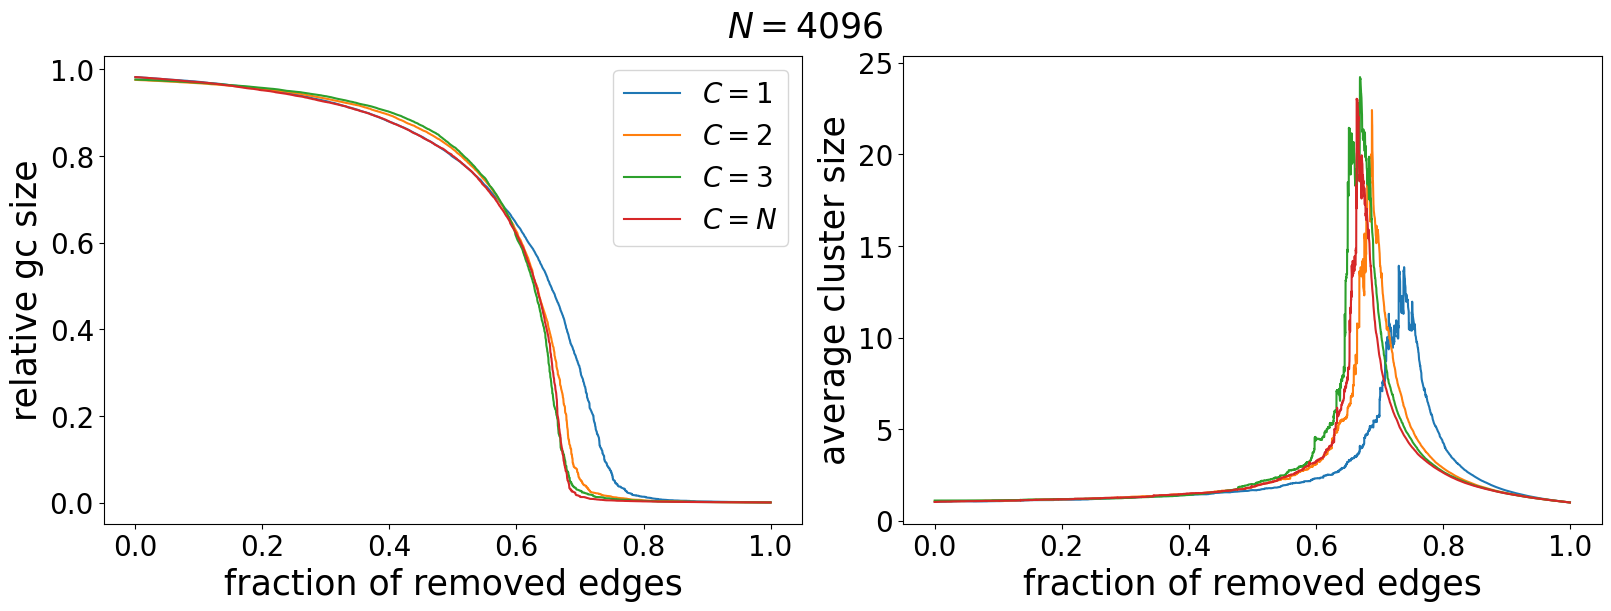

In [10]:
C1_dfs = [compute_average_curves(N=N, avg_k=avg_k, C=1) for N in [1024, 2048, 4096]]
C2_dfs = [compute_average_curves(N=N, avg_k=avg_k, C=2) for N in [1024, 2048, 4096]]
C3_dfs = [compute_average_curves(N=N, avg_k=avg_k, C=3) for N in [1024, 2048, 4096]]
CN_dfs = [compute_average_curves(N=N, avg_k=avg_k, C=N) for N in [1024, 2048, 4096]]


fig, ax = plt.subplots(ncols=2, figsize=(16, 6), constrained_layout=True)

fig.suptitle(f'$N=4096$', fontsize=25)

ax[0].plot(C1_dfs[-1]["p"], C1_dfs[-1]["m1"], label='$C=1$')
ax[0].plot(C2_dfs[-1]["p"], C2_dfs[-1]["m1"], label='$C=2$')
ax[0].plot(C3_dfs[-1]["p"], C3_dfs[-1]["m1"], label='$C=3$')
ax[0].plot(CN_dfs[-1]["p"], CN_dfs[-1]["m1"], label='$C=N$')

ax[0].set_xlabel("fraction of removed edges", fontsize=25)
ax[0].set_ylabel("relative gc size", fontsize=25)
ax[0].tick_params("both", labelsize=20)
ax[0].legend(fontsize=20)


ax[1].plot(C1_dfs[-1]["p"], C1_dfs[-1]["s"], label='$C=1$')
ax[1].plot(C2_dfs[-1]["p"], C2_dfs[-1]["s"], label='$C=2$')
ax[1].plot(C3_dfs[-1]["p"], C3_dfs[-1]["s"], label='$C=3$')
ax[1].plot(CN_dfs[-1]["p"], CN_dfs[-1]["s"], label='$C=N$')

ax[1].set_xlabel("fraction of removed edges", fontsize=25)
ax[1].set_ylabel("average cluster size", fontsize=25)
ax[1].tick_params("both", labelsize=20)

plt.show()

🔍 Comparing different network sizes for fixed costs

In this visualization we compare networks of size $N = 1024$, $2048$, and $4096$ for two different cost regimes:  

- **Left panel:** $C = 1$;
- **Right panel:** $C = N$.

On the x-axis we use the **raw number of demands ($t$)** with a logarithmic scale, and on the y-axis we show the corresponding **fraction of removed edges ($p$)**.  

This comparison highlights how the network size $N$ influences the scaling of the process under small-cost and large-cost scenarios.


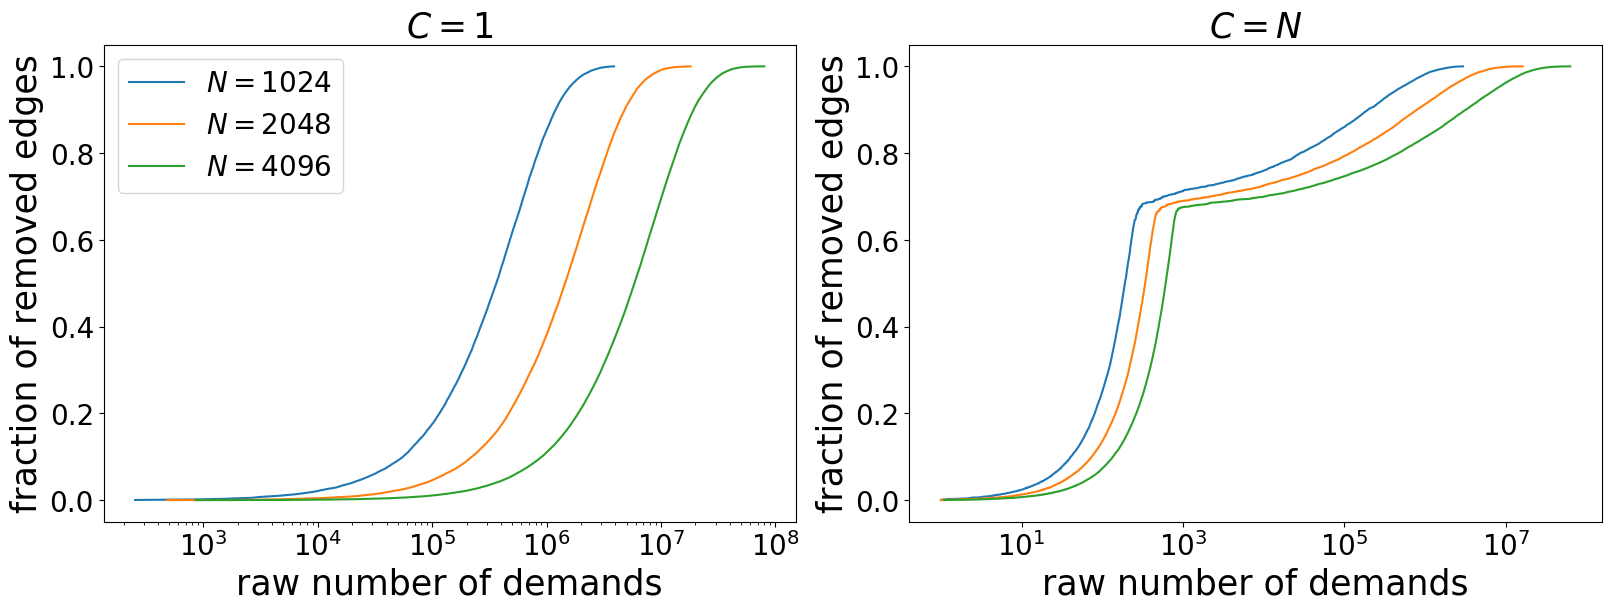

In [26]:
fig, ax = plt.subplots(ncols=2, figsize=(16, 6), constrained_layout=True)

ax[0].plot(C1_dfs[0]["t"], C1_dfs[0]["p"], label='$N=1024$')
ax[0].plot(C1_dfs[1]["t"], C1_dfs[1]["p"], label='$N=2048$')
ax[0].plot(C1_dfs[2]["t"], C1_dfs[2]["p"], label='$N=4096$')

ax[0].set_title('$C=1$', fontsize=25)
ax[0].set_xlabel("raw number of demands", fontsize=25)
ax[0].set_ylabel("fraction of removed edges", fontsize=25)
ax[0].tick_params("both", labelsize=20)
ax[0].set_xscale('log')
ax[0].legend(fontsize=20)


ax[1].plot(CN_dfs[0]["t"], CN_dfs[0]["p"], label='$N=1024$')
ax[1].plot(CN_dfs[1]["t"], CN_dfs[1]["p"], label='$N=2048$')
ax[1].plot(CN_dfs[2]["t"], CN_dfs[2]["p"], label='$N=4006$')

ax[1].set_title('$C=N$', fontsize=25)
ax[1].set_xlabel("raw number of demands", fontsize=25)
ax[1].set_ylabel("fraction of removed edges", fontsize=25)
ax[1].tick_params("both", labelsize=20)
ax[1].set_xscale('log')

plt.show()

# ⚖️ Finite-size scaling analysis with rescaled demands

In this figure we explore the effect of **rescaling the raw number of demands ($t$)**  
by powers of the system size $N$. This allows us to perform a finite-size scaling analysis.  

- **Left panel ($C=1$):** $t \cdot N^{-2}$ vs. fraction of removed edges ($p$);
- **Middle panel ($C=N$):** $t \cdot N^{-0.86}$ vs. fraction of removed edges ($p$);  
- **Right panel ($C=N$):** $t \cdot N^{-2}$ vs. fraction of removed edges ($p$).  

Using a **logarithmic scale** on the x-axis makes it possible to compare systems of different sizes  
and observe whether the curves collapse under the chosen scaling exponents.


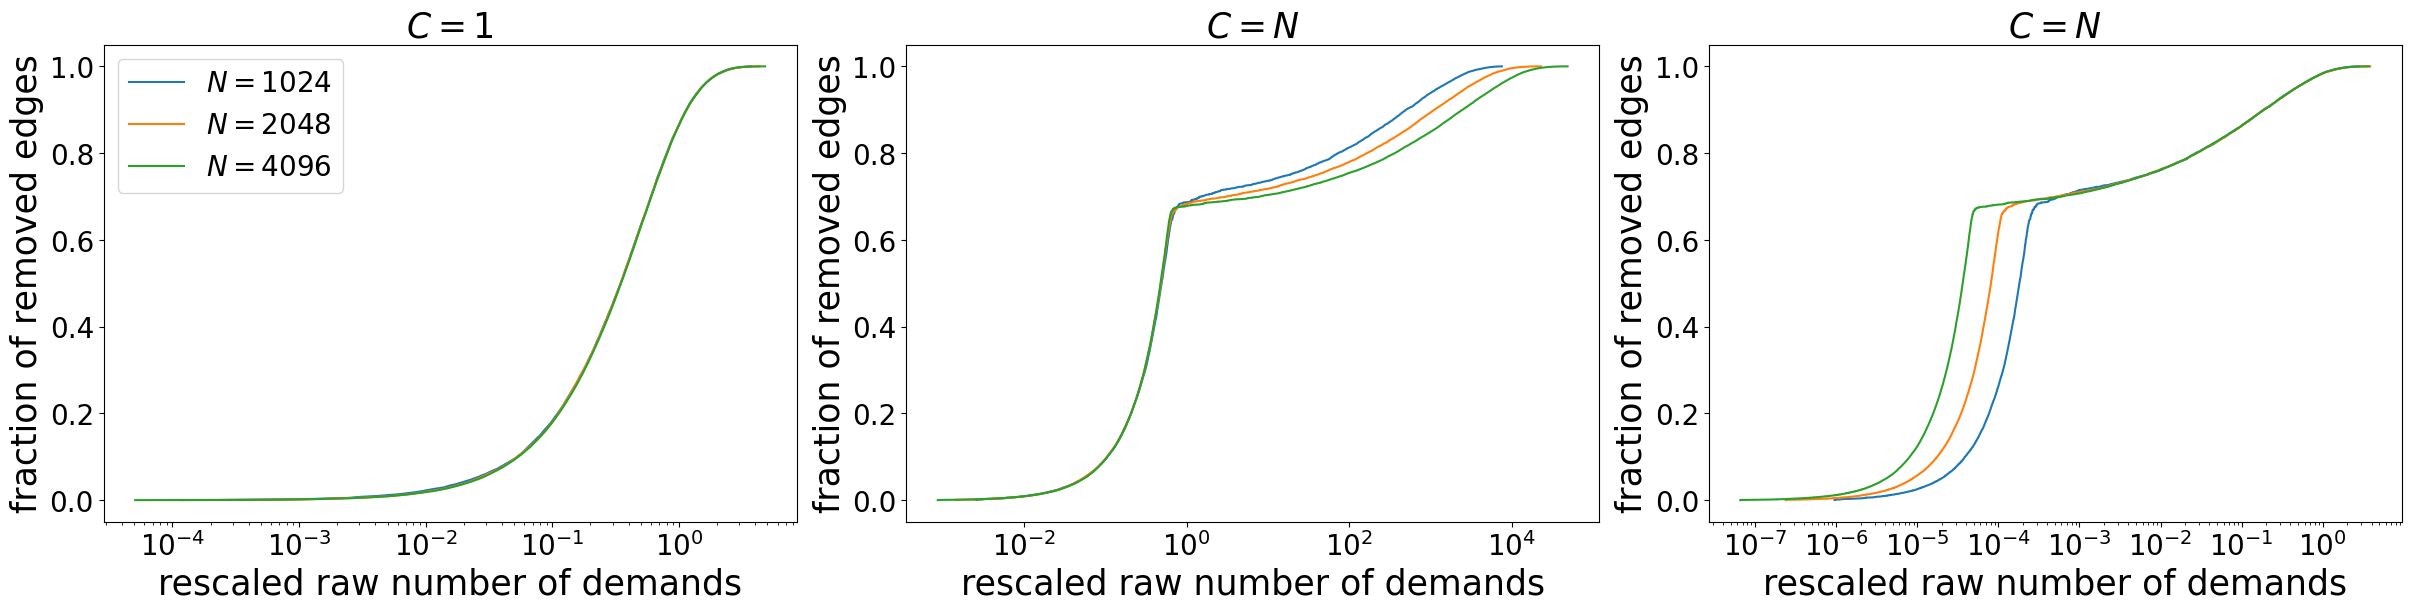

In [25]:
fig, ax = plt.subplots(ncols=3, figsize=(24, 6), constrained_layout=True)

ax[0].plot(C1_dfs[0]["t"] * np.power(1024, -2.), C1_dfs[0]["p"], label='$N=1024$')
ax[0].plot(C1_dfs[1]["t"] * np.power(2048, -2.), C1_dfs[1]["p"], label='$N=2048$')
ax[0].plot(C1_dfs[2]["t"] * np.power(4096, -2.), C1_dfs[2]["p"], label='$N=4096$')

ax[0].set_title('$C=1$', fontsize=25)
ax[0].set_xlabel("rescaled raw number of demands", fontsize=25)
ax[0].set_ylabel("fraction of removed edges", fontsize=25)
ax[0].tick_params("both", labelsize=20)
ax[0].set_xscale('log')
ax[0].legend(fontsize=20)


ax[1].plot(CN_dfs[0]["t"] * np.power(1024, -0.86), CN_dfs[0]["p"], label='$N=1024$')
ax[1].plot(CN_dfs[1]["t"] * np.power(2048, -0.86), CN_dfs[1]["p"], label='$N=2048$')
ax[1].plot(CN_dfs[2]["t"] * np.power(4096, -0.86), CN_dfs[2]["p"], label='$N=4096$')

ax[1].set_title('$C=N$', fontsize=25)
ax[1].set_xlabel("rescaled raw number of demands", fontsize=25)
ax[1].set_ylabel("fraction of removed edges", fontsize=25)
ax[1].tick_params("both", labelsize=20)
ax[1].set_xscale('log')

ax[2].plot(CN_dfs[0]["t"] * np.power(1024, -2.), CN_dfs[0]["p"], label='$N=1024$')
ax[2].plot(CN_dfs[1]["t"] * np.power(2048, -2.), CN_dfs[1]["p"], label='$N=2048$')
ax[2].plot(CN_dfs[2]["t"] * np.power(4096, -2.), CN_dfs[2]["p"], label='$N=4096$')

ax[2].set_title('$C=N$', fontsize=25)
ax[2].set_xlabel("rescaled raw number of demands", fontsize=25)
ax[2].set_ylabel("fraction of removed edges", fontsize=25)
ax[2].tick_params("both", labelsize=20)
ax[2].set_xscale('log')

plt.show()